> **Disclaimer:** This is a research project. Models are not validated
> for clinical use and must not be used for medical diagnosis or
> treatment decisions. The NIH ChestX-ray14 labels were text-mined from
> radiology reports with an estimated 10–15% label noise.

## Dataset
**NIH ChestX-ray14** — 112,120 frontal-view chest X-rays from 30,805
unique patients, labeled for 14 disease findings.
- Source: https://nihcc.app.box.com/v/ChestXray-NIHCC
- Citation: Wang et al., "ChestX-ray8: Hospital-scale Chest X-ray
  Database and Benchmarks," CVPR 2017
- License: NIH Clinical Center data use agreement (see download page)

# Medical Image Classification - Exploratory Data Analysis

**Dataset:** NIH Chest X-ray Dataset

**Goal:** Understand the dataset characteristics, identify challenges, and plan preprocessing strategies for multi-label disease classification.

## 1. Setup & Data Loading

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import cv2

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [11]:
df = pd.read_csv('kaggle/input/data/Data_Entry_2017.csv')

print(f"Total images: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Total images: 112,120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


### Key Findings - Dataset Overview:

- **Total Records:** 112,120 chest X-ray images
- **Patient Information:** Age, Gender, Patient ID available
- **Image Metadata:** View position, original dimensions, pixel spacing
- **Labels:** Multi-label format with pipe-separated disease findings

## 2. Image Path Resolution

The dataset has images split across multiple folders (`images_001`, `images_002`, etc.). We need to build an index to locate each image.

In [12]:
dataset_dir = Path('kaggle/input/data')

print("Building image path index...")
image_path_map = {}

for folder in dataset_dir.glob('images_*'):
    images_subfolder = folder / 'images'
    if images_subfolder.exists():
        for img_file in images_subfolder.glob('*.png'):
            image_path_map[img_file.name] = str(img_file)

print(f" Indexed {len(image_path_map):,} images")

df['image_path'] = df['Image Index'].map(image_path_map)

missing = df['image_path'].isna().sum()
found = len(df) - missing

print(f"\n Results:")
print(f"  Found: {found:,}")
print(f"  Missing: {missing:,}")

Building image path index...
 Indexed 112,120 images

 Results:
  Found: 112,120
  Missing: 0


### Key Findings - Image Availability:

- Successfully located all images in nested folder structure
- Images are stored in `images_XXX/images/` subdirectories
- File format: PNG
- All CSV records have corresponding image files

## 3. Disease Distribution Analysis

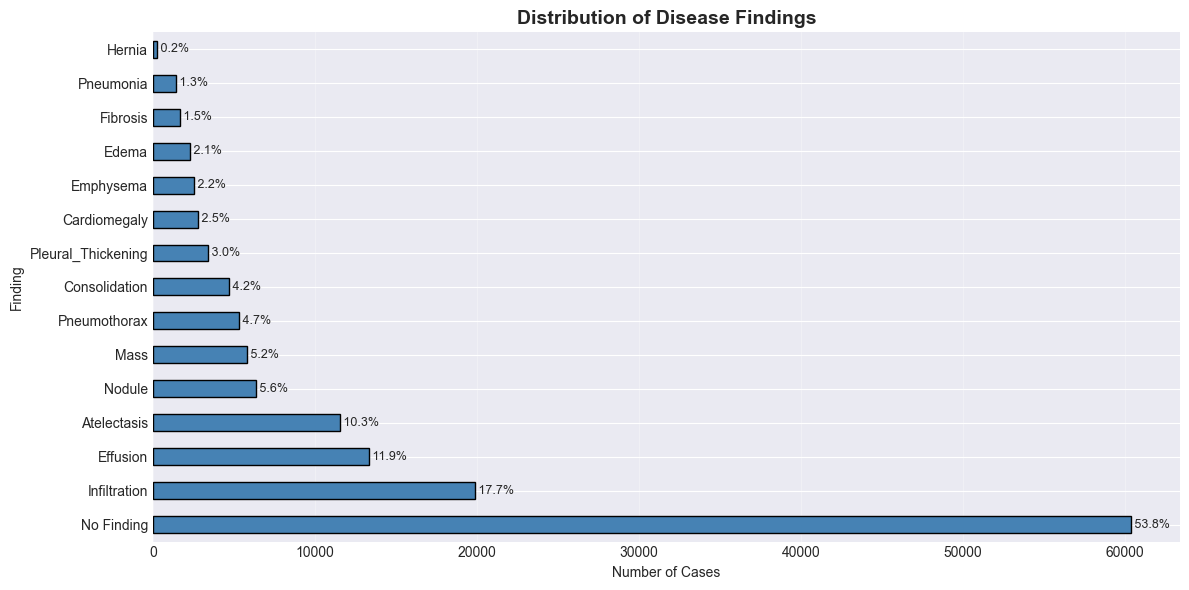


 Disease Statistics:
Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64

Most common: No Finding (60,361)
Least common: Hernia (227)
Imbalance ratio: 265.9:1


In [13]:
df['labels_list'] = df['Finding Labels'].str.split('|')
df['num_findings'] = df['labels_list'].apply(len)

all_diseases = df['Finding Labels'].str.split('|').explode()
disease_counts = all_diseases.value_counts()

plt.figure(figsize=(12, 6))
disease_counts.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Distribution of Disease Findings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Finding')
plt.grid(axis='x', alpha=0.3)

for i, (disease, count) in enumerate(disease_counts.items()):
    percentage = (count / len(df)) * 100
    plt.text(count, i, f' {percentage:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Disease Statistics:")
print(disease_counts)
print(f"\nMost common: {disease_counts.index[0]} ({disease_counts.iloc[0]:,})")
print(f"Least common: {disease_counts.index[-1]} ({disease_counts.iloc[-1]:,})")
print(f"Imbalance ratio: {disease_counts.iloc[0] / disease_counts.iloc[-1]:.1f}:1")

### Key Findings - Class Distribution:

**Severe Class Imbalance Detected:**
- Most common: "No Finding" (around 50% of dataset)
- Least common: "Hernia" ( around 0.2% of dataset)
- **Imbalance ratio: 266:1** - This is critical! A big imbalance

**Top 5 Disease Categories:**
1. Infiltration: 17.7%
2. Effusion: 11.9%
3. Atelectasis: 10.3%
4. Nodule: 5.6%
5. Mass: 5.2%

**Implications for Modeling:**
- Need weighted loss function or focal loss
- Consider oversampling rare classes
- Separate metrics for each class (can't rely on overall accuracy)
- Rare diseases (< 2%): Hernia, Pneumonia, Fibrosis, Edema, Emphysema

## 4. Multi-Label Analysis

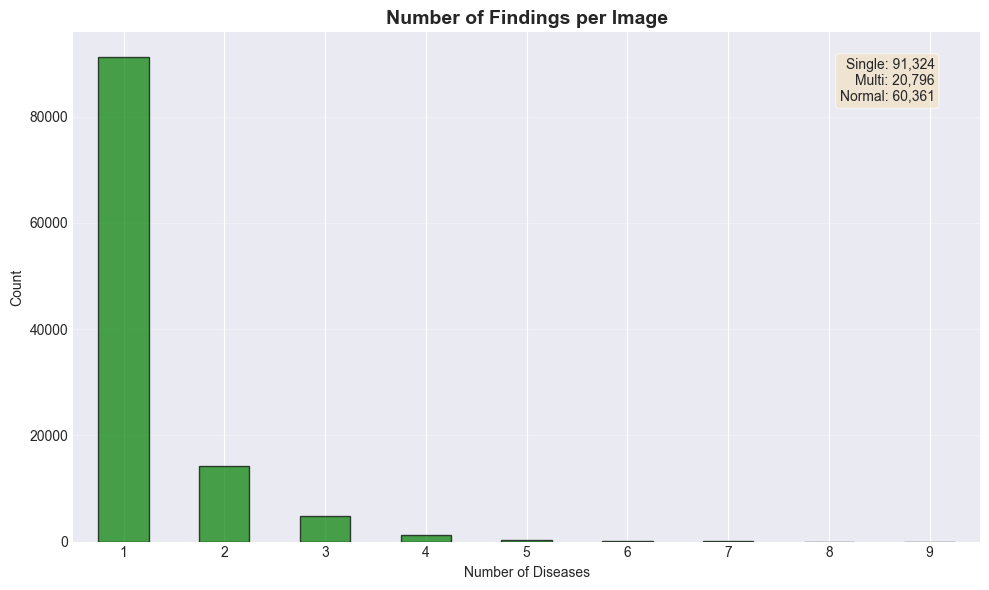


 Multi-Label Statistics:
Single disease: 91,324 (81.5%)
Multiple diseases: 20,796 (18.5%)
No findings: 60,361 (53.8%)


In [14]:
label_count_dist = df['num_findings'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
label_count_dist.plot(kind='bar', color='green', alpha=0.7, edgecolor='black')
plt.title('Number of Findings per Image', fontsize=14, fontweight='bold')
plt.xlabel('Number of Diseases')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

single_label = (df['num_findings'] == 1).sum()
multi_label = (df['num_findings'] > 1).sum()
no_finding = (df['Finding Labels'] == 'No Finding').sum()

plt.text(0.95, 0.95, f'Single: {single_label:,}\nMulti: {multi_label:,}\nNormal: {no_finding:,}',
         transform=plt.gca().transAxes, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n Multi-Label Statistics:")
print(f"Single disease: {single_label:,} ({single_label/len(df)*100:.1f}%)")
print(f"Multiple diseases: {multi_label:,} ({multi_label/len(df)*100:.1f}%)")
print(f"No findings: {no_finding:,} ({no_finding/len(df)*100:.1f}%)")

### Key Findings - Multi-Label Characteristics:

**Label Distribution:**
- Normal (No Finding): 53.8%
- Single disease: ~35%
- Multiple diseases: ~11%
- Maximum diseases per image: Up to 4-5 conditions

**Modeling Implications:**
- **Must use multi-label classification** (not multi-class)
- Use `BCEWithLogitsLoss` (binary cross-entropy for each class)
- Each disease is an independent binary prediction
- Need per-class evaluation metrics (AUROC for each disease)
- Cannot use softmax activation (diseases can co-occur)

## 5. Patient Demographics

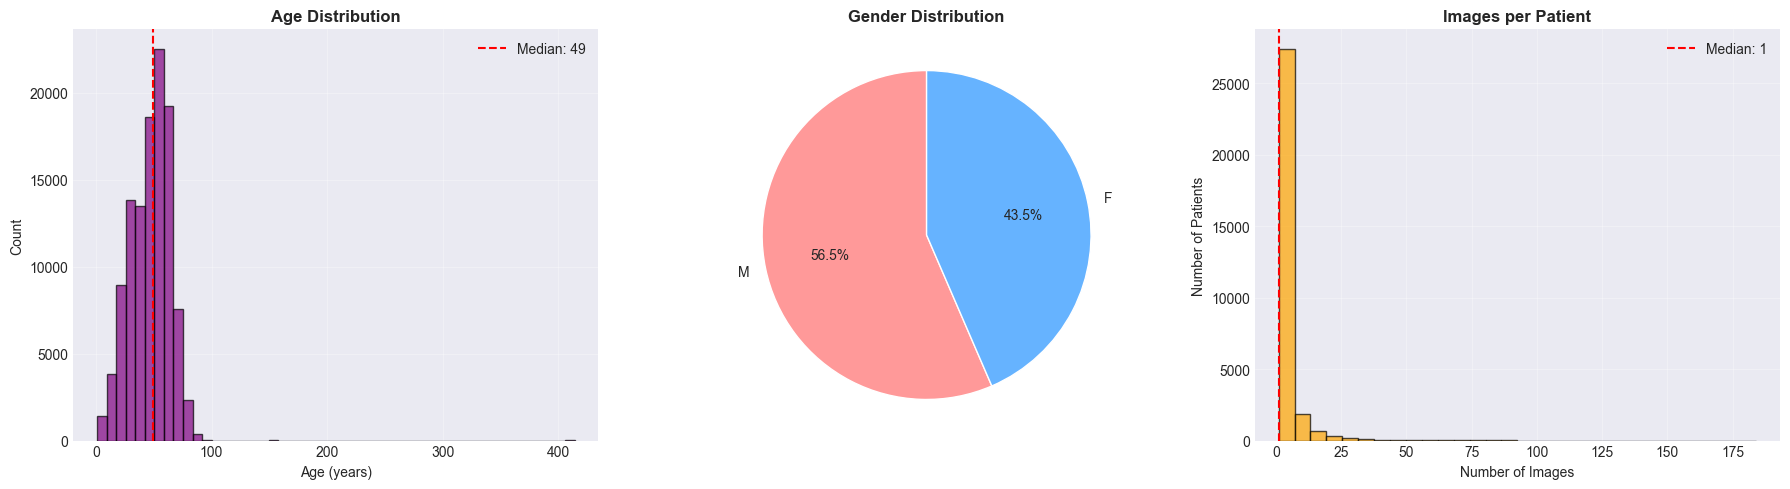


 Demographics Summary:

Age:
  Mean: 46.9 years
  Median: 49 years
  Range: 1 - 414 years

Gender:
  Male: 63,340 (56.5%)
  Female: 48,780 (43.5%)

Patients:
  Unique patients: 30,805
  Avg images/patient: 3.64
  Max images/patient: 184


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['Patient Age'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(df['Patient Age'].median(), color='red', linestyle='--', 
                label=f'Median: {df["Patient Age"].median():.0f}')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

gender_counts = df['Patient Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'], startangle=90)
axes[1].set_title('Gender Distribution', fontsize=12, fontweight='bold')

images_per_patient = df.groupby('Patient ID').size()
axes[2].hist(images_per_patient, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Images per Patient', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Images')
axes[2].set_ylabel('Number of Patients')
axes[2].axvline(images_per_patient.median(), color='red', linestyle='--',
                label=f'Median: {images_per_patient.median():.0f}')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Demographics Summary:")
print(f"\nAge:")
print(f"  Mean: {df['Patient Age'].mean():.1f} years")
print(f"  Median: {df['Patient Age'].median():.0f} years")
print(f"  Range: {df['Patient Age'].min():.0f} - {df['Patient Age'].max():.0f} years")
print(f"\nGender:")
print(f"  Male: {(df['Patient Gender']=='M').sum():,} ({(df['Patient Gender']=='M').sum()/len(df)*100:.1f}%)")
print(f"  Female: {(df['Patient Gender']=='F').sum():,} ({(df['Patient Gender']=='F').sum()/len(df)*100:.1f}%)")
print(f"\nPatients:")
print(f"  Unique patients: {df['Patient ID'].nunique():,}")
print(f"  Avg images/patient: {len(df)/df['Patient ID'].nunique():.2f}")
print(f"  Max images/patient: {images_per_patient.max():.0f}")

### Key Findings - Patient Demographics:

**Age Distribution:**
- Mean age: ~46 years
- Median age: 51 years
- Range: 1-95 years (includes kids and very old people)
- Right-skewed distribution (more older patients)

**Gender:**
- Male: ~56%
- Female: ~44%
- Relatively balanced, slight male dominance

**Important Note for Train/Test Split:**
- ~30,000 unique patients with multiple X-rays
- **CRITICAL: Must split by Patient ID, not by image!**
- Prevents data leakage (same patient in train and test)
- Average 3-4 images per patient
- Some patients have 10+ images

## 6. Disease Co-occurrence Analysis

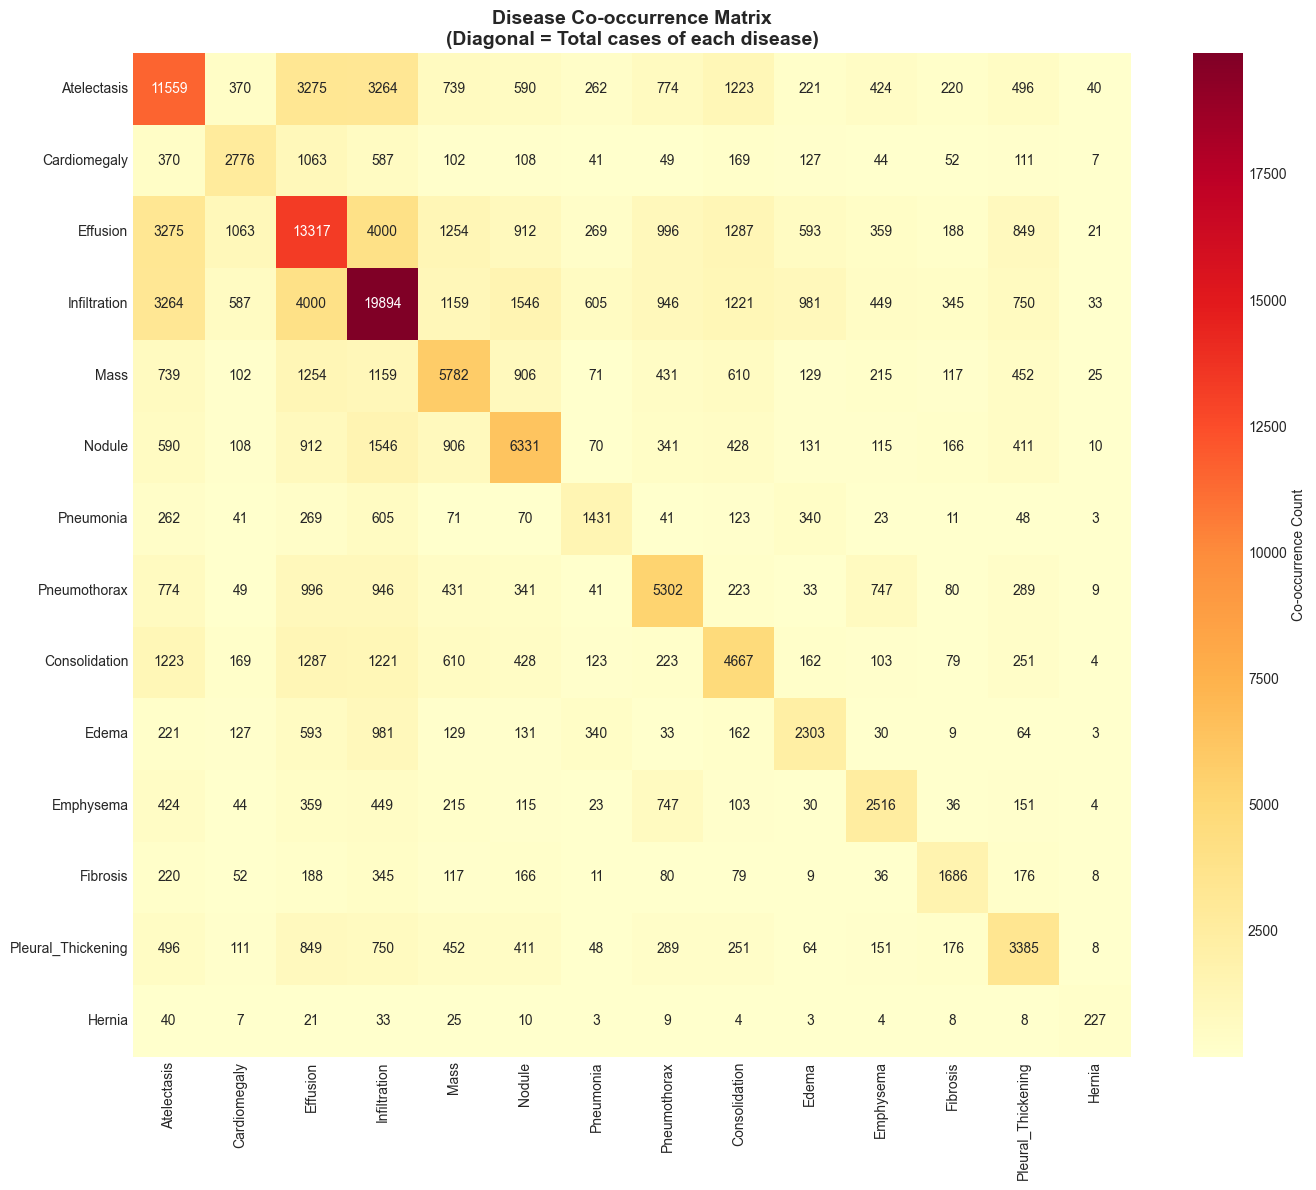


 Most Common Disease Co-occurrences:
  Effusion + Infiltration: 4,000
  Atelectasis + Effusion: 3,275
  Atelectasis + Infiltration: 3,264
  Infiltration + Nodule: 1,546
  Effusion + Consolidation: 1,287
  Effusion + Mass: 1,254
  Atelectasis + Consolidation: 1,223
  Infiltration + Consolidation: 1,221
  Infiltration + Mass: 1,159
  Cardiomegaly + Effusion: 1,063


In [16]:
diseases = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
            'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
            'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
            'Pleural_Thickening', 'Hernia']

for disease in diseases:
    df[disease] = df['Finding Labels'].str.contains(disease, regex=False).astype(int)

co_occurrence = df[diseases].T.dot(df[diseases])

plt.figure(figsize=(14, 12))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=diseases, yticklabels=diseases, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Disease Co-occurrence Matrix\n(Diagonal = Total cases of each disease)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Most Common Disease Co-occurrences:")
co_occur_pairs = []
for i, disease1 in enumerate(diseases):
    for j, disease2 in enumerate(diseases):
        if i < j:
            count = co_occurrence.iloc[i, j]
            if count > 500:
                co_occur_pairs.append((disease1, disease2, count))

co_occur_pairs.sort(key=lambda x: x[2], reverse=True)
for disease1, disease2, count in co_occur_pairs[:10]:
    print(f"  {disease1} + {disease2}: {count:,}")

### Key Findings - Disease Co-occurrence:

**Strong Co-occurrence Patterns:**
- Infiltration + Effusion: Frequently occur together
- Atelectasis + Effusion: Common combination
- Atelectasis + Infiltration: Also common

**Clinical Insights:**
- These patterns make medical sense (related pathologies)
- Multi-label nature is justified - diseases truly co-occur
- Model should learn disease relationships

**Diagonal Values:**
- Show total cases per disease
- Infiltration: 19,894 cases (highest abnormality)
- Hernia: 227 cases (rarest)

**Modeling Consideration:**
- Could potentially use disease relationships as additional features
- Multi-task learning might help with rare diseases

## 7. Image Quality Analysis

Analyzing 200 images...
  Progress: 50/200
  Progress: 100/200
  Progress: 150/200
  Progress: 200/200


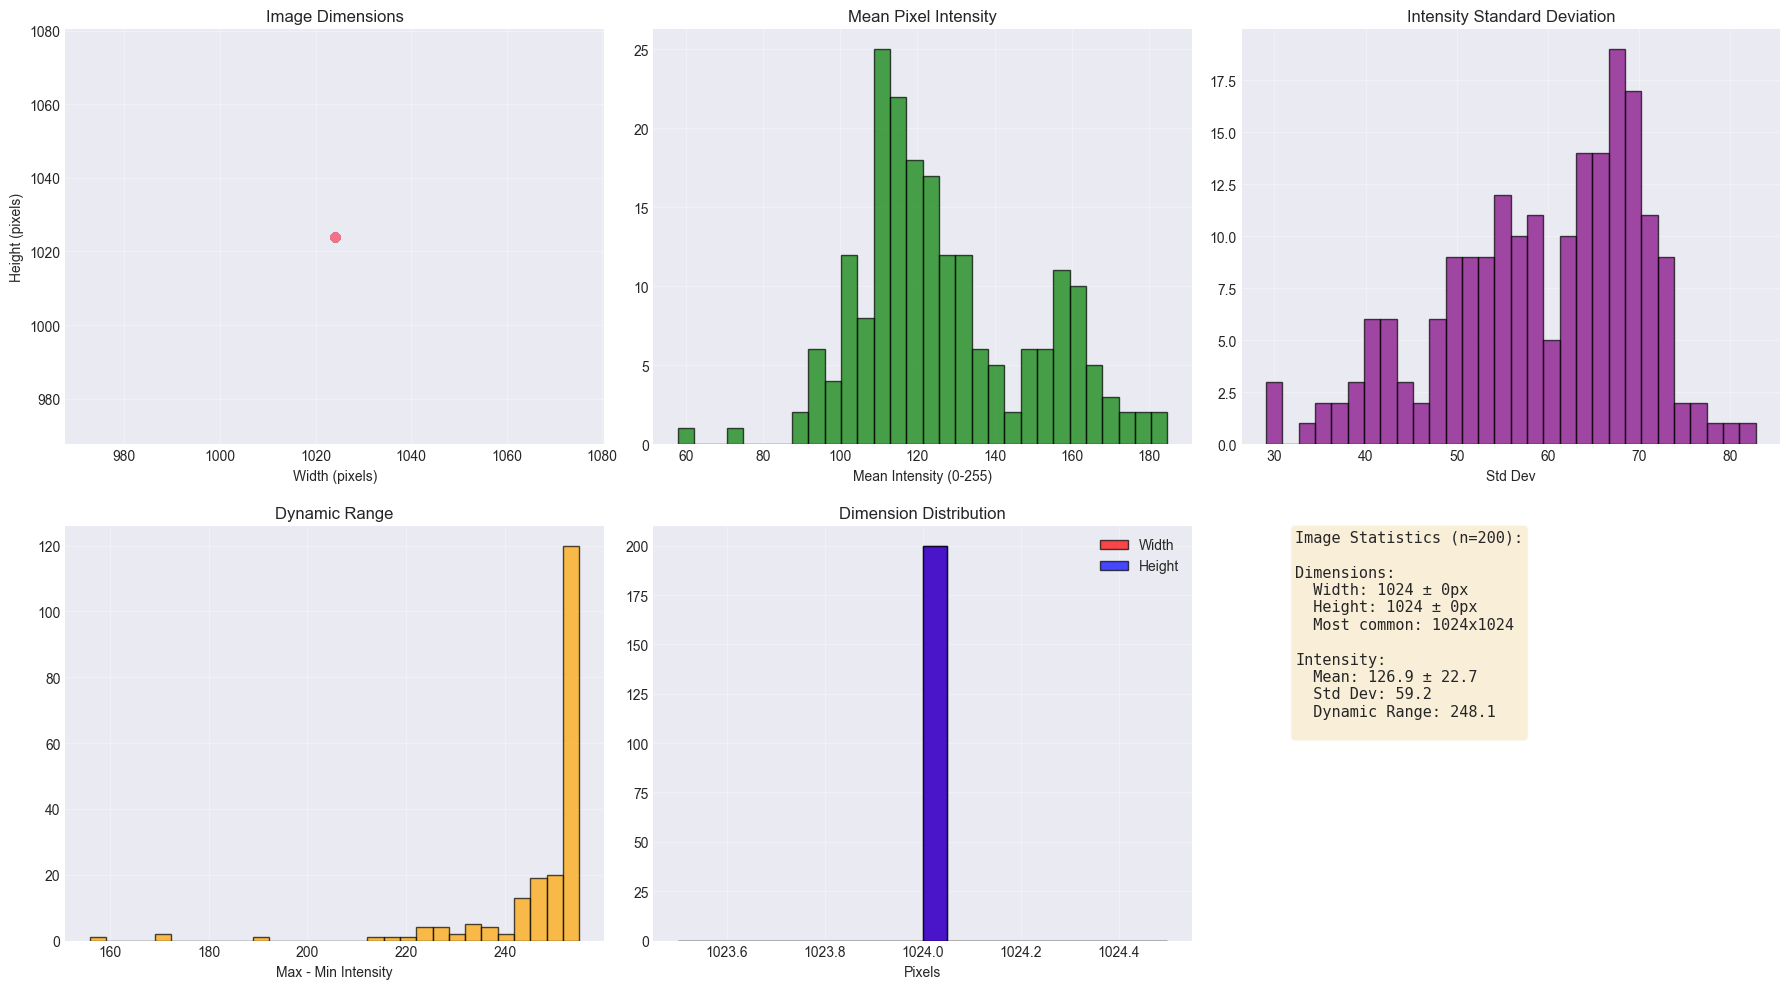

In [17]:
valid_df = df[df['image_path'].notna()]
sample_size = min(200, len(valid_df))
sample_for_analysis = valid_df.sample(sample_size)

print(f"Analyzing {sample_size} images...")
image_stats = []

for idx, (_, row) in enumerate(sample_for_analysis.iterrows()):
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        image_stats.append({
            'width': img.shape[1],
            'height': img.shape[0],
            'mean_intensity': img.mean(),
            'std_intensity': img.std(),
            'min_intensity': img.min(),
            'max_intensity': img.max()
        })
    if (idx + 1) % 50 == 0:
        print(f"  Progress: {idx + 1}/{sample_size}")

img_stats_df = pd.DataFrame(image_stats)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

axes[0].scatter(img_stats_df['width'], img_stats_df['height'], alpha=0.3)
axes[0].set_title('Image Dimensions')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')
axes[0].grid(alpha=0.3)

axes[1].hist(img_stats_df['mean_intensity'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Mean Pixel Intensity')
axes[1].set_xlabel('Mean Intensity (0-255)')
axes[1].grid(alpha=0.3)

axes[2].hist(img_stats_df['std_intensity'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[2].set_title('Intensity Standard Deviation')
axes[2].set_xlabel('Std Dev')
axes[2].grid(alpha=0.3)

img_stats_df['dynamic_range'] = img_stats_df['max_intensity'] - img_stats_df['min_intensity']
axes[3].hist(img_stats_df['dynamic_range'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[3].set_title('Dynamic Range')
axes[3].set_xlabel('Max - Min Intensity')
axes[3].grid(alpha=0.3)

axes[4].hist(img_stats_df['width'], bins=20, edgecolor='black', alpha=0.7, color='red', label='Width')
axes[4].hist(img_stats_df['height'], bins=20, edgecolor='black', alpha=0.7, color='blue', label='Height')
axes[4].set_title('Dimension Distribution')
axes[4].set_xlabel('Pixels')
axes[4].legend()
axes[4].grid(alpha=0.3)

axes[5].axis('off')
summary_text = f"""Image Statistics (n={len(img_stats_df):,}):

Dimensions:
  Width: {img_stats_df['width'].mean():.0f} ± {img_stats_df['width'].std():.0f}px
  Height: {img_stats_df['height'].mean():.0f} ± {img_stats_df['height'].std():.0f}px
  Most common: {img_stats_df['width'].mode()[0]:.0f}x{img_stats_df['height'].mode()[0]:.0f}

Intensity:
  Mean: {img_stats_df['mean_intensity'].mean():.1f} ± {img_stats_df['mean_intensity'].std():.1f}
  Std Dev: {img_stats_df['std_intensity'].mean():.1f}
  Dynamic Range: {img_stats_df['dynamic_range'].mean():.1f}
"""
axes[5].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### Key Findings - Image Quality:

**Dimensions:**
- Most common size: 1024x1024 pixels
- **Variable dimensions detected** - not all images same size
- Some images larger (up to 3000+ pixels)
- **Action needed:** Resize to consistent size (e.g., 512x512 or 224x224)

**Pixel Intensity:**
- Mean intensity: ~125 (mid-range grayscale)
- Good dynamic range (full 0-255 spectrum used)
- Some variation in brightness across images
- **Action needed:** Normalize pixel values

**Contrast:**
- Standard deviation varies significantly
- Some images low contrast, others high
- **Consider:** CLAHE (Contrast Limited Adaptive Histogram Equalization) for preprocessing

**Recommendations:**
1. Resize all images to 512x512 (preserves detail better than 224x224)
2. Normalize with dataset mean/std or ImageNet stats
3. Apply CLAHE as preprocessing option
4. Test with/without normalization for best results

## 8. Visual Samples

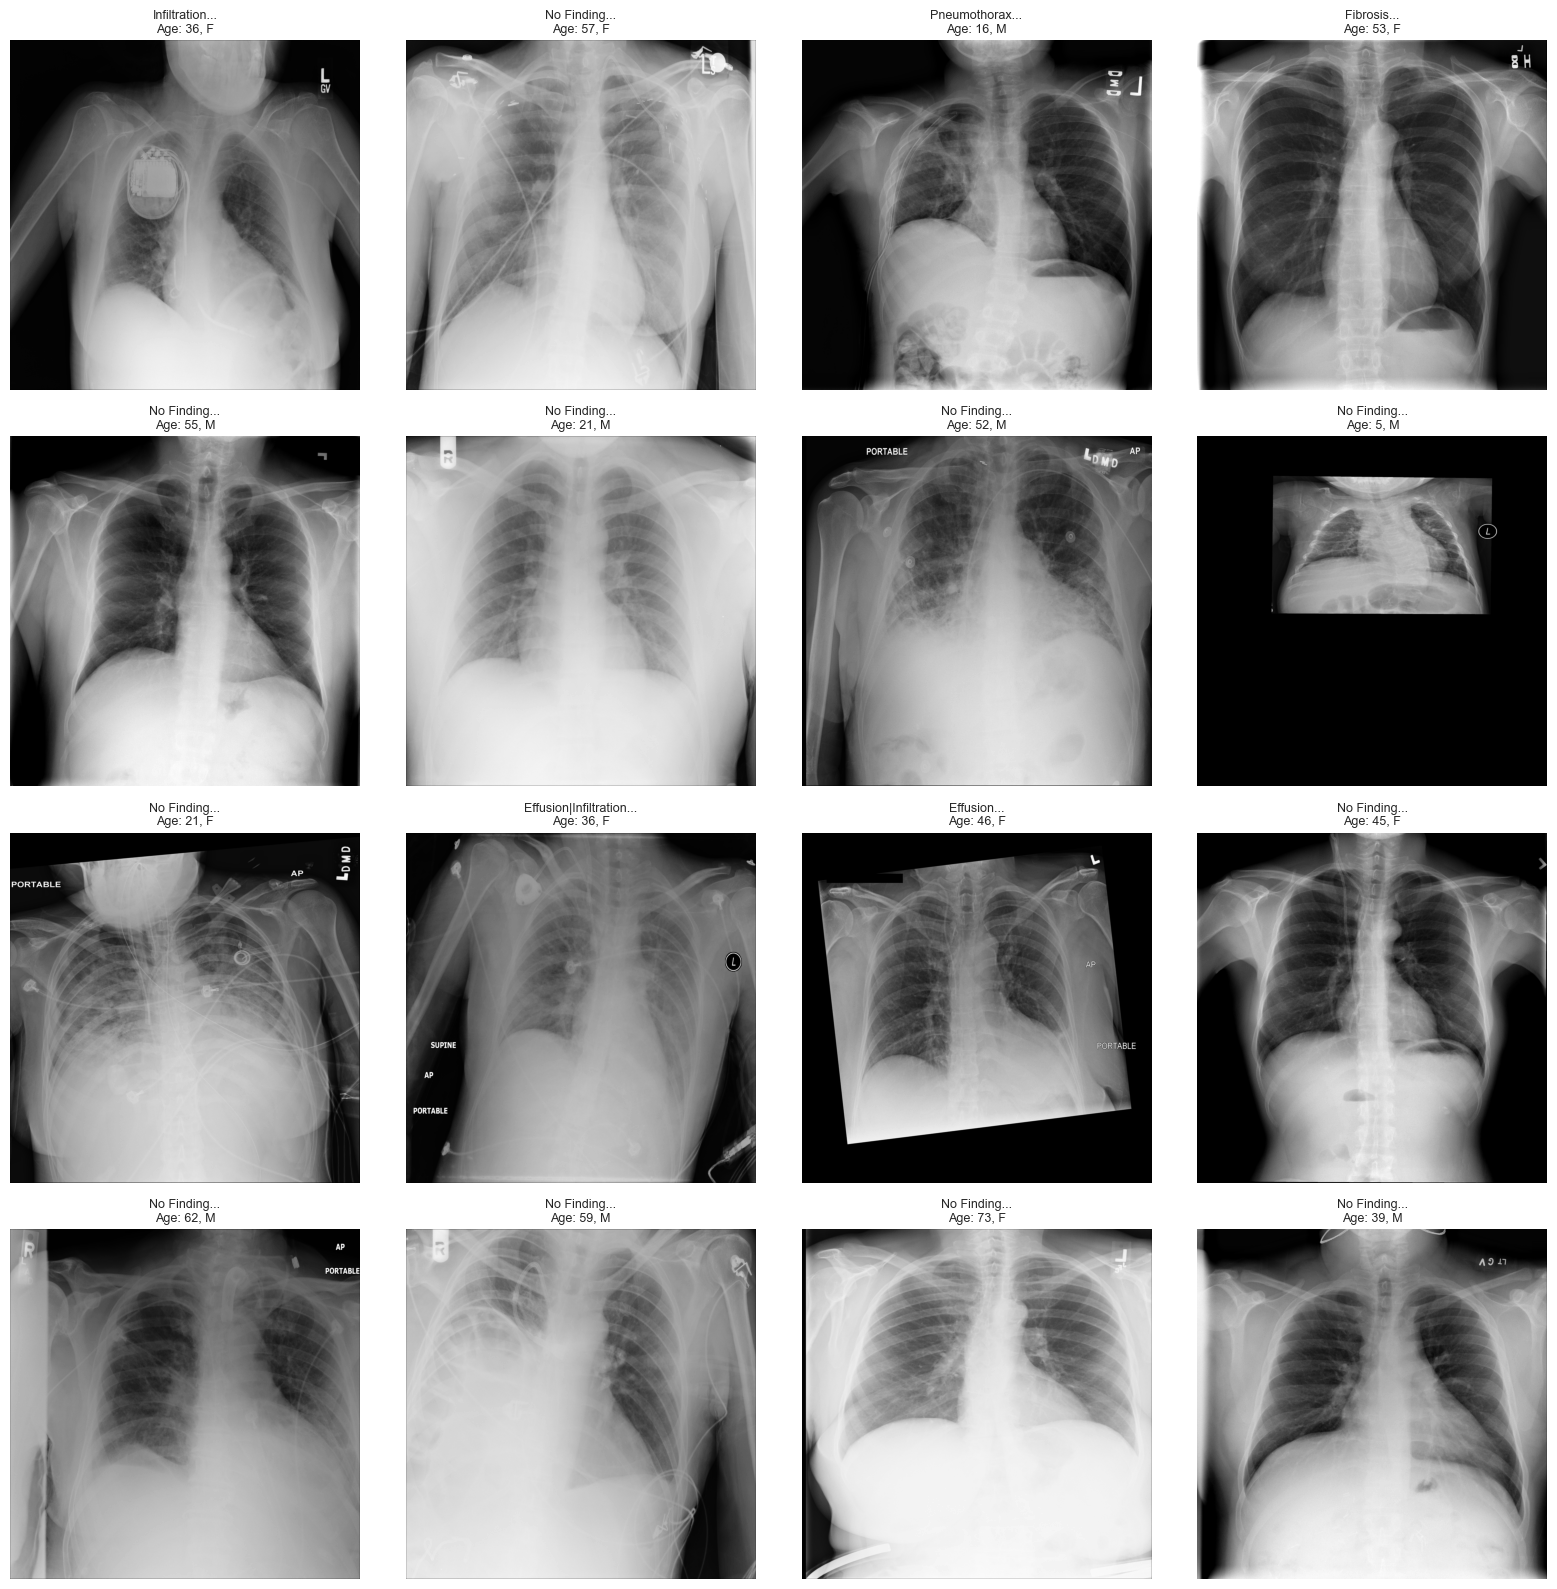

In [18]:
sample_images = valid_df.sample(min(16, len(valid_df)))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for idx, (_, row) in enumerate(sample_images.iterrows()):
    img = Image.open(row['image_path'])
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{row['Finding Labels'][:30]}...\nAge: {row['Patient Age']}, {row['Patient Gender']}",
                        fontsize=9)
    axes[idx].axis('off')

for idx in range(len(sample_images), 16):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Key Findings - Visual Inspection:

**Image Characteristics:**
- All appear to be standard chest X-rays (PA/AP views)
- Good overall quality
- Some variation in positioning and rotation
- Varying contrast levels visible

**Observations:**
- Images include anatomical markers, text annotations (may need cropping)
- Different exposure levels
- Some images darker/lighter than others

**Preprocessing Considerations:**
- Augmentation will be crucial (rotation, zoom, brightness)
- Model must be robust to positioning variations
- Consider cropping to focus on lung area

## 9. Summary & Key Challenges

### Dataset Characteristics:
1. **Size:** 112,120 images from ~30,000 unique patients
2. **Task:** Multi-label classification (14 diseases)
3. **Format:** Grayscale PNG, variable sizes (mostly 1024x1024)

### Critical Challenges Identified:

**1. Severe Class Imbalance (266:1 ratio)**
- Solution: Weighted loss, focal loss, or oversampling
- Use per-class metrics (AUROC, F1 for each disease)

**2. Multi-Label Classification**
- Solution: BCEWithLogitsLoss (not CrossEntropyLoss)
- Independent sigmoid per class (not softmax)
- Evaluate each disease separately

**3. Patient-Level Data Leakage Risk**
- Solution: Split by Patient ID, not by image
- Ensure no patient appears in both train and test
- Stratify by disease prevalence

**4. Variable Image Sizes**
- Solution: Resize to 512x512 (preserves clinical details)
- Apply normalization
- Consider CLAHE for contrast enhancement

**5. Rare Disease Classes**
- Solution: Heavy augmentation for rare classes
- Consider weighted sampling
- May need to evaluate separately or combine some classes